<a href="https://colab.research.google.com/github/ThuanNP/dann-mnist-mnistm/blob/main/notebooks/dann_mnist_to_mnistm_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tái lập DANN trên MNIST → MNIST-M

Notebook tái lập thí nghiệm MNIST → MNIST-M của Ganin và Lempitsky (2015) với mạng nơ-ron đối kháng miền
(Domain-Adversarial Neural Network, DANN), từ dựng dữ liệu, huấn luyện ba mô hình đến phân tích kết quả.
Toàn bộ mã nằm trong notebook; mỗi bước đi kèm công thức và cách tính tương ứng trong bài báo.

**Cách chạy trên Google Colab.** Chọn *Runtime > Change runtime type > T4 GPU*, rồi *Runtime > Run all*.
Notebook tự tải MNIST và BSDS500, không cần tệp hay thư viện cài thêm. Thời gian huấn luyện đo được ghi ở
bảng kết quả mục 7.

**Ba mô hình dùng chung một kiến trúc:**

| Mô hình | Dữ liệu huấn luyện | Vai trò |
| :--- | :--- | :--- |
| `baseline` | MNIST có nhãn | Cận dưới: không thích ứng |
| `dann` | MNIST có nhãn và MNIST-M không nhãn | Thích ứng tên miền không giám sát |
| `target` | MNIST-M có nhãn | Cận trên: học trực tiếp trên miền đích |

Mã nguồn đầy đủ (ứng dụng Streamlit, checkpoint, kết quả nhiều seed) ở repo
[ThuanNP/dann-mnist-mnistm](https://github.com/ThuanNP/dann-mnist-mnistm). Notebook viết lại phần huấn
luyện theo cách nạp toàn bộ dữ liệu lên GPU để chạy nhanh trên Colab, nên số liệu gần với repo nhưng không
trùng từng chữ số.

## 1. Bài toán và cơ sở lý thuyết

**Thích ứng tên miền không giám sát.** Miền nguồn $\mathcal{D}_S$ có mẫu gán nhãn
$\{(x_i, y_i)\}_{i=1}^{n_s}$, miền đích $\mathcal{D}_T$ chỉ có mẫu không nhãn $\{x_j\}_{j=1}^{n_t}$. Hai miền
chung không gian nhãn (10 chữ số) nhưng khác phân phối đầu vào: $P_S(X) \neq P_T(X)$. Mục tiêu là một bộ
phân loại có sai số thấp trên miền đích. Trong thí nghiệm này, miền nguồn là MNIST (chữ số trắng trên nền
đen), miền đích là MNIST-M (chữ số trộn với mảnh ảnh màu), $n_s = n_t = 60\,000$.

**Cận trên của rủi ro miền đích.** Ganin và cộng sự (2016, Định lý 2), dựa trên Ben-David và cộng sự (2006),
phát biểu: với lớp giả thuyết $\mathcal{H}$ có chiều VC $d$, với xác suất $1-\delta$ trên cách chọn mẫu
$S \sim (\mathcal{D}_S)^n$ và $T \sim (\mathcal{D}_T^X)^n$, mọi $\eta \in \mathcal{H}$ thỏa

$$
R_{\mathcal{D}_T}(\eta) \le R_S(\eta)
+ \sqrt{\frac{4}{n}\left(d \log\frac{2en}{d} + \log\frac{4}{\delta}\right)}
+ \hat{d}_{\mathcal{H}}(S, T)
+ 4\sqrt{\frac{1}{n}\left(d \log\frac{2n}{d} + \log\frac{4}{\delta}\right)}
+ \beta,
\qquad
\beta \ge \inf_{\eta^* \in \mathcal{H}} \left[R_{\mathcal{D}_S}(\eta^*) + R_{\mathcal{D}_T}(\eta^*)\right].
$$

Số hạng $\hat{d}_{\mathcal{H}}(S, T)$ là độ phân kỳ $\mathcal{H}$ thực nghiệm giữa hai mẫu: hai miền càng khó
phân biệt bằng một bộ phân loại trong $\mathcal{H}$ thì số hạng này càng nhỏ. DANN nhắm vào số hạng này bằng
cách học biểu diễn mà bộ phân loại miền không phân biệt được, đồng thời giữ rủi ro nguồn $R_S(\eta)$ thấp.

**Kiến trúc và hàm mục tiêu.** DANN gồm bộ trích đặc trưng $G_f(\cdot;\theta_f)$, bộ dự đoán nhãn
$G_y(\cdot;\theta_y)$ và bộ phân loại miền $G_d(\cdot;\theta_d)$. Nhãn miền $d_i = 0$ với mẫu nguồn, $d_i = 1$
với mẫu đích. Ganin và Lempitsky (2015, phương trình 1 đến 3) tìm điểm yên ngựa của phiếm hàm

$$
E(\theta_f,\theta_y,\theta_d) = \sum_{i:\,d_i=0} L_y^i(\theta_f,\theta_y) - \lambda \sum_{i=1}^{N} L_d^i(\theta_f,\theta_d),
$$

$$
(\hat\theta_f, \hat\theta_y) = \arg\min_{\theta_f,\theta_y} E(\theta_f,\theta_y,\hat\theta_d),
\qquad
\hat\theta_d = \arg\max_{\theta_d} E(\hat\theta_f,\hat\theta_y,\theta_d).
$$

$L_y$ là mất mát hồi quy logistic đa lớp (entropy chéo), $L_d$ là entropy chéo nhị phân. Tại điểm yên ngựa,
$\theta_d$ cực tiểu mất mát phân loại miền, còn $\theta_f$ vừa cực tiểu mất mát dự đoán nhãn, vừa cực đại
mất mát phân loại miền; $\lambda$ điều hòa hai mục tiêu.

**Tầng đảo ngược gradient (Gradient Reversal Layer, GRL).** Điểm yên ngựa là điểm dừng của các cập nhật
(phương trình 4 đến 6)

$$
\theta_f \leftarrow \theta_f - \mu\left(\frac{\partial L_y^i}{\partial \theta_f} - \lambda \frac{\partial L_d^i}{\partial \theta_f}\right),
\qquad
\theta_y \leftarrow \theta_y - \mu \frac{\partial L_y^i}{\partial \theta_y},
\qquad
\theta_d \leftarrow \theta_d - \mu \frac{\partial L_d^i}{\partial \theta_d}.
$$

GRL đặt giữa $G_f$ và $G_d$, được định nghĩa như một "giả hàm" với hai phương trình cho hai chiều lan truyền
(phương trình 7, 8): $R_\lambda(x) = x$ và $\dfrac{dR_\lambda}{dx} = -\lambda I$. Nhờ GRL, chỉ cần chạy SGD
thông thường trên

$$
\tilde{E}(\theta_f,\theta_y,\theta_d) = \sum_{i:\,d_i=0} L_y\big(G_y(G_f(x_i)), y_i\big) + \sum_{i=1}^{N} L_d\big(G_d(R_\lambda(G_f(x_i))), d_i\big)
$$

là thực hiện đúng ba cập nhật trên (phương trình 9). Mã ở mục 4 cài đúng tổng này: `loss = loss_y + loss_d`.

## 2. Cấu hình và môi trường

Các siêu tham số lấy từ mục 4 và Phụ lục C của Ganin và Lempitsky (2015). `SEEDS` và `NORM` là hai lựa chọn
bài báo không cố định:

- Bài báo không nêu số seed. `SEEDS = [42]` huấn luyện mỗi mô hình một lần; `[42, 43, 44]` lặp lại ba seed như repo.
- Bài báo ghi "mean subtraction" mà không nêu cách tính trung bình. `NORM = "half"` trừ 0,5 ở mỗi kênh;
  `NORM = "mean"` trừ trung bình từng kênh trên tập train gộp của hai miền (công thức ở mục 3.4).
- Bài báo không nêu số bước huấn luyện cho MNIST → MNIST-M. `EPOCHS = 20` tính theo số lượt duyệt tập nguồn;
  lịch tốc độ học và $\lambda$ tính theo tổng số bước.

In [1]:
import copy
import io
import json
import math
import os
import platform
import random
import tarfile
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from PIL import Image
from torch import nn
from torchvision import datasets

SEEDS = [42]           # [42, 43, 44] để lặp lại ba seed
NORM = "half"          # "half" hoặc "mean"
EPOCHS = 20
BATCH = 128            # DANN: 64 ảnh nguồn + 64 ảnh đích mỗi bước
MU0, ALPHA, BETA = 0.01, 10.0, 0.75   # lịch tốc độ học (Phụ lục C)
GAMMA = 10.0                          # lịch hệ số thích ứng (phương trình 14)
MOMENTUM = 0.9
MNISTM_SEED = 0        # seed cắt mảnh BSDS500 khi dựng MNIST-M
DATA_DIR, OUT_DIR = Path("data"), Path("results")
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cpu":
    print("Không có GPU: chọn Runtime > Change runtime type > T4 GPU (chạy trên CPU rất chậm).")

env = {"python": platform.python_version(), "torch": torch.__version__, "cuda": torch.version.cuda,
       "cudnn": torch.backends.cudnn.version(),
       "device": torch.cuda.get_device_name(0) if device.type == "cuda" else "cpu"}
pd.DataFrame([env])

,python,torch,cuda,cudnn,device
0,3.14.7,2.14.0+cu130,13.0,92400,NVIDIA RTX A4000 Laptop GPU


In [2]:
def set_seed(seed):
    # Cố định seed cho random, NumPy, PyTorch và buộc cuDNN chạy tất định
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## 3. Dữ liệu

### 3.1. MNIST (miền nguồn)

MNIST (LeCun và cộng sự, 1998) gồm ảnh xám 28×28 của chữ số viết tay, 60 000 ảnh train và 10 000 ảnh test.
Để dùng chung kiến trúc với MNIST-M, mỗi ảnh được lặp thành ba kênh giống nhau.

In [3]:
mnist_tr = datasets.MNIST(DATA_DIR, train=True, download=True)
mnist_te = datasets.MNIST(DATA_DIR, train=False, download=True)
print("MNIST train", tuple(mnist_tr.data.shape), " test", tuple(mnist_te.data.shape))

MNIST train (60000, 28, 28)  test (10000, 28, 28)


### 3.2. Dựng MNIST-M (miền đích)

Ganin và Lempitsky (2015, mục 4.1) tạo MNIST-M bằng cách trộn chữ số MNIST với mảnh cắt ngẫu nhiên từ ảnh màu
của BSDS500 (Arbelaez và cộng sự, 2011). Với hai ảnh $I^1$ (chữ số, lặp thành ba kênh) và $I^2$ (mảnh ảnh
màu cùng kích thước), ảnh kết quả là

$$
I^{\text{out}}_{ijk} = \left| I^1_{ijk} - I^2_{ijk} \right|,
$$

với $i, j$ là tọa độ điểm ảnh và $k$ là chỉ số kênh. Nơi chữ số trắng ($I^1 = 255$), màu nền bị đảo; nơi nền
đen ($I^1 = 0$), mảnh ảnh giữ nguyên. Chữ số vì thế không còn là "trắng trên đen" mà mang màu và kết cấu của
ảnh chụp.

Hai bản bài báo không nêu thêm chi tiết cài đặt. Notebook và repo chọn: mảnh 28×28 cắt ở độ phân giải gốc
của ảnh BSDS500; nền của tập train lấy từ 200 ảnh BSDS500 `train`, nền của tập test lấy từ 200 ảnh `test`,
nên hai tập không chung ảnh nền. Tệp BSDS500 (khoảng 70 MB) tải từ trang BSDS500 của Đại học California, Berkeley.

In [4]:
BSDS_URL = ("https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/grouping/BSR/"
            "BSR_bsds500.tgz")
SIZE = 28


def bsds_images(split):
    tgz = DATA_DIR / "BSR_bsds500.tgz"
    if not tgz.exists():
        print("Tải BSDS500 ...")
        urllib.request.urlretrieve(BSDS_URL, tgz)
    out = []
    with tarfile.open(tgz) as tar:
        for m in tar.getmembers():
            if f"BSDS500/data/images/{split}/" in m.name and m.name.endswith(".jpg"):
                out.append(np.asarray(Image.open(tar.extractfile(m)).convert("RGB")))
    return out


def blend(digits, backgrounds, rng):
    # I_out = |I1 - I2|, I2 là mảnh 28x28 cắt ngẫu nhiên từ một ảnh nền chọn ngẫu nhiên
    out = np.empty((len(digits), SIZE, SIZE, 3), dtype=np.uint8)
    for n, d in enumerate(digits):
        bg = backgrounds[rng.integers(len(backgrounds))]
        y = rng.integers(bg.shape[0] - SIZE + 1)
        x = rng.integers(bg.shape[1] - SIZE + 1)
        patch = bg[y:y + SIZE, x:x + SIZE].astype(np.int16)
        out[n] = np.abs(d[:, :, None].astype(np.int16) - patch).astype(np.uint8)
    return out


t0 = time.time()
rng = np.random.default_rng(MNISTM_SEED)
bg_train, bg_test = bsds_images("train"), bsds_images("test")
mnistm_tr = blend(mnist_tr.data.numpy(), bg_train, rng)
mnistm_te = blend(mnist_te.data.numpy(), bg_test, rng)
print(f"Ảnh nền BSDS500: {len(bg_train)} train, {len(bg_test)} test")
print(f"MNIST-M train {mnistm_tr.shape}, test {mnistm_te.shape} ({time.time() - t0:.0f} s)")

Ảnh nền BSDS500: 200 train, 200 test
MNIST-M train (60000, 28, 28, 3), test (10000, 28, 28, 3) (4 s)


Hình 1 minh họa phép trộn trên ba chữ số: cột giữa là mảnh ảnh nền $I^2$, cột phải là
$\left| I^1 - I^2 \right|$. Các mảnh trong hình cắt bằng một bộ sinh số ngẫu nhiên riêng, không ảnh hưởng tập
dữ liệu vừa dựng.

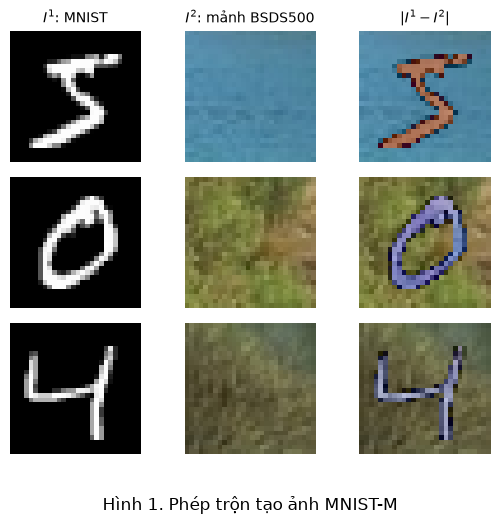

In [5]:
demo_rng = np.random.default_rng(123)
fig, ax = plt.subplots(3, 3, figsize=(5.4, 5.4))
for r, idx in enumerate([0, 1, 2]):
    d = mnist_tr.data[idx].numpy()
    bg = bg_train[demo_rng.integers(len(bg_train))]
    y, x = demo_rng.integers(bg.shape[0] - SIZE + 1), demo_rng.integers(bg.shape[1] - SIZE + 1)
    patch = bg[y:y + SIZE, x:x + SIZE]
    out = np.abs(d[:, :, None].astype(np.int16) - patch.astype(np.int16)).astype(np.uint8)
    for c, (img, title) in enumerate([(d, "$I^1$: MNIST"), (patch, "$I^2$: mảnh BSDS500"),
                                      (out, "$|I^1 - I^2|$")]):
        ax[r, c].imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax[r, c].axis("off")
        if r == 0:
            ax[r, c].set_title(title, fontsize=10)
fig.suptitle("Hình 1. Phép trộn tạo ảnh MNIST-M", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### 3.3. Mô tả dữ liệu

Hai miền dùng chung nhãn: ảnh MNIST-M thứ $n$ mang nhãn của ảnh MNIST thứ $n$, nên phân bố lớp của hai miền
trùng nhau. Khác biệt giữa hai miền nằm ở phân phối đầu vào $P(X)$: màu, độ tương phản và kết cấu nền.

In [6]:
y_tr, y_te = mnist_tr.targets.numpy(), mnist_te.targets.numpy()
sizes = pd.DataFrame({
    "Miền": ["Nguồn", "Đích"], "Bộ dữ liệu": ["MNIST", "MNIST-M"],
    "Ảnh train": [len(y_tr), len(mnistm_tr)], "Ảnh test": [len(y_te), len(mnistm_te)],
    "Kích thước": ["28×28×1 (lặp thành 3 kênh)", "28×28×3"],
    "Nhãn dùng khi huấn luyện DANN": ["Có", "Không"]})
display(sizes)

counts = pd.DataFrame({"train": np.bincount(y_tr), "test": np.bincount(y_te)})
counts.index.name = "Chữ số"
display(counts.T)

,Miền,Bộ dữ liệu,Ảnh train,Ảnh test,Kích thước,Nhãn dùng khi huấn luyện DANN
0,Nguồn,MNIST,60000,10000,28×28×1 (lặp thành 3 kênh),Có
1,Đích,MNIST-M,60000,10000,28×28×3,Không


Chữ số,0,1,2,3,4,5,6,7,8,9
train,5923,6742,5958,6131,5842,5421,5918,6265,5851,5949
test,980,1135,1032,1010,982,892,958,1028,974,1009


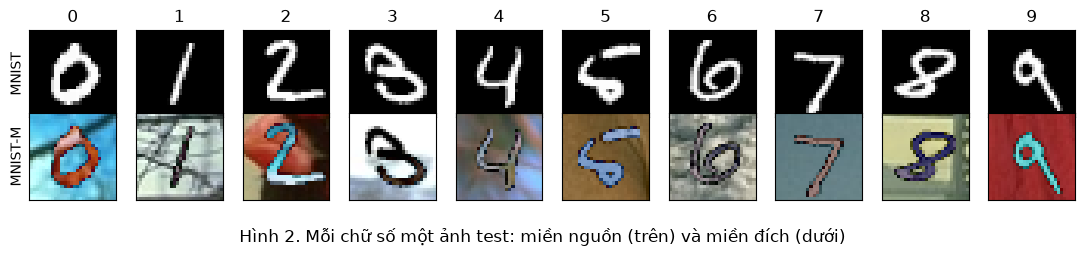

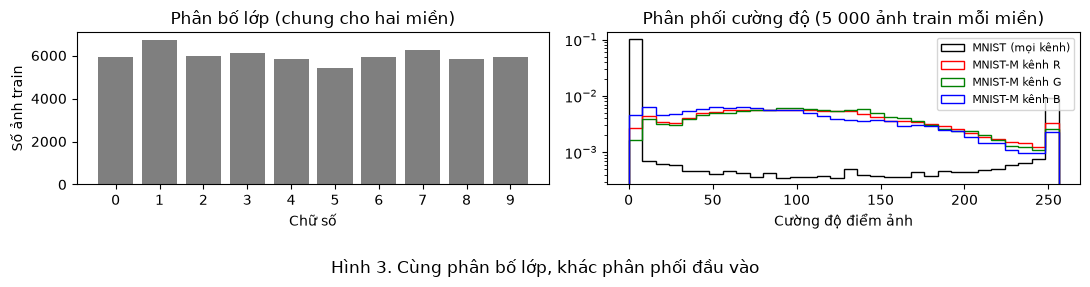

Kênh,R,G,B
"Trung bình cường độ (thang [0, 1])",,,
MNIST,0.1307,0.1307,0.1307
MNIST-M,0.4356,0.4391,0.3838


In [7]:
fig, ax = plt.subplots(2, 10, figsize=(11, 2.6))
for k in range(10):
    i = int(np.where(y_te == k)[0][0])
    ax[0, k].imshow(mnist_te.data[i], cmap="gray")
    ax[1, k].imshow(mnistm_te[i])
    ax[0, k].set_title(str(k))
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([])
ax[0, 0].set_ylabel("MNIST")
ax[1, 0].set_ylabel("MNIST-M")
fig.suptitle("Hình 2. Mỗi chữ số một ảnh test: miền nguồn (trên) và miền đích (dưới)", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].bar(range(10), counts["train"], color="tab:gray")
ax[0].set_xticks(range(10)); ax[0].set_xlabel("Chữ số"); ax[0].set_ylabel("Số ảnh train")
ax[0].set_title("Phân bố lớp (chung cho hai miền)")
bins = np.arange(0, 257, 8)
ax[1].hist(mnist_tr.data[:5000].numpy().ravel(), bins=bins, density=True, histtype="step",
           color="k", label="MNIST (mọi kênh)")
for k, c in enumerate(["red", "green", "blue"]):
    ax[1].hist(mnistm_tr[:5000, :, :, k].ravel(), bins=bins, density=True, histtype="step",
               color=c, label=f"MNIST-M kênh {'RGB'[k]}")
ax[1].set_yscale("log"); ax[1].set_xlabel("Cường độ điểm ảnh"); ax[1].legend(fontsize=8)
ax[1].set_title("Phân phối cường độ (5 000 ảnh train mỗi miền)")
fig.suptitle("Hình 3. Cùng phân bố lớp, khác phân phối đầu vào", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

stats = pd.DataFrame({
    "MNIST": [mnist_tr.data.float().div(255).mean().item()] * 3,
    "MNIST-M": mnistm_tr.mean(axis=(0, 1, 2)) / 255}, index=["R", "G", "B"])
stats.index.name = "Kênh"
display(stats.round(4).T.rename_axis("Trung bình cường độ (thang [0, 1])"))

MNIST gần như chỉ có hai mức cường độ (nền 0, nét chữ gần 255), còn MNIST-M trải đều trên toàn thang và khác
nhau giữa ba kênh. Đây là lệch miền (domain shift) mà mô hình chỉ học trên MNIST phải đối mặt.

### 3.4. Tiền xử lý

Ganin và Lempitsky (2015, mục 4) chỉ ghi ảnh được tiền xử lý bằng phép trừ trung bình. Với ảnh $x$ ở thang
$[0, 1]$, đầu vào của mạng là $x'_{ijk} = x_{ijk} - m_k$, với

- `NORM = "half"`: $m_k = 0{,}5$ ở mọi kênh;
- `NORM = "mean"`: $m_k = \dfrac{\sum_{x \in S_{\text{train}}} \sum_{i,j} x_{ijk} + \sum_{x \in T_{\text{train}}} \sum_{i,j} x_{ijk}}{(n_s + n_t) \cdot 28 \cdot 28}$,
  trung bình kênh $k$ trên tập train gộp của hai miền (không dùng nhãn).

Toàn bộ ảnh được giữ trên GPU ở dạng `uint8` và chỉ chuẩn hóa khi lấy từng batch.

In [8]:
if NORM == "half":
    MEAN = (0.5, 0.5, 0.5)
else:
    s_mnist = mnist_tr.data.double().div(255).sum().item()
    s_mnistm = mnistm_tr.sum(axis=(0, 1, 2), dtype=np.float64) / 255
    MEAN = tuple(((s_mnist + s_mnistm) / ((len(mnist_tr.data) + len(mnistm_tr)) * SIZE * SIZE)).tolist())
print("NORM =", NORM, " m =", tuple(round(m, 4) for m in MEAN))

to_dev = lambda a: torch.as_tensor(a).to(device)
S_tr, S_te = to_dev(mnist_tr.data[:, None]), to_dev(mnist_te.data[:, None])            # N x 1 x 28 x 28
T_tr = to_dev(np.ascontiguousarray(mnistm_tr.transpose(0, 3, 1, 2)))                      # N x 3 x 28 x 28
T_te = to_dev(np.ascontiguousarray(mnistm_te.transpose(0, 3, 1, 2)))
yS_tr, yS_te = to_dev(mnist_tr.targets), to_dev(mnist_te.targets)
yT_tr, yT_te = yS_tr.clone(), yS_te.clone()   # MNIST-M giữ nhãn MNIST
MEAN_T = torch.tensor(MEAN, device=device).view(1, 3, 1, 1)


def prep(xb):
    # uint8 -> float [0, 1], lặp ảnh xám thành 3 kênh, trừ trung bình kênh
    x = xb.float().div(255)
    if x.shape[1] == 1:
        x = x.expand(-1, 3, -1, -1)
    return x - MEAN_T

NORM = half  m = (0.5, 0.5, 0.5)


## 4. Mô hình

Kiến trúc cho MNIST theo phần phụ lục của Ganin và Lempitsky (2015):

- Bộ trích đặc trưng $G_f$: conv 5×5, 32 kênh → ReLU → max-pool 2×2 → conv 5×5, 48 kênh → ReLU → max-pool 2×2.
- Bộ dự đoán nhãn $G_y$: FC 100 → ReLU → FC 100 → ReLU → FC 10.
- Bộ phân loại miền $G_d$: GRL → FC 100 → ReLU → FC 1 (hồi quy logistic).

GRL cài bằng `torch.autograd.Function`: chiều xuôi trả lại đầu vào, chiều ngược nhân gradient với $-\lambda$,
đúng hai phương trình $R_\lambda(x) = x$ và $dR_\lambda/dx = -\lambda I$. Mô hình `baseline` và `target` dùng
cùng lớp `DANN` nhưng bỏ qua nhánh miền.

In [9]:
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


def grad_reverse(x, lambd):
    return GradReverse.apply(x, lambd)


class DANN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(                      # G_f
            nn.Conv2d(3, 32, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 48, 5), nn.ReLU(), nn.MaxPool2d(2, 2), nn.Flatten())
        self.classifier = nn.Sequential(                    # G_y
            nn.Linear(48 * 4 * 4, 100), nn.ReLU(), nn.Linear(100, 100), nn.ReLU(),
            nn.Linear(100, n_classes))
        self.domain = nn.Sequential(                        # G_d (sau GRL)
            nn.Linear(48 * 4 * 4, 100), nn.ReLU(), nn.Linear(100, 1))

    def forward(self, x, lambd=0.0, with_domain=False):
        f = self.features(x)
        logits = self.classifier(f)
        if with_domain:
            return logits, self.domain(grad_reverse(f, lambd)).squeeze(1)
        return logits

In [10]:
# Bảng kiến trúc: kích thước đầu ra và số tham số từng tầng
rows, m = [], DANN()
x = torch.zeros(1, 3, 28, 28)
for branch, seq in [("G_f", m.features), ("G_y", m.classifier), ("G_d", m.domain)]:
    h = x if branch == "G_f" else m.features(x)
    for layer in seq:
        h = layer(h)
        rows.append({"Nhánh": branch, "Tầng": layer.__class__.__name__,
                     "Đầu ra": "×".join(map(str, h.shape[1:])),
                     "Tham số": sum(p.numel() for p in layer.parameters())})
arch = pd.DataFrame(rows)
display(arch)
print("Tổng số tham số:", sum(p.numel() for p in m.parameters()))

# Kiểm tra GRL: gradient của sum(R_lambda(x)) theo x phải bằng -lambda
xg = torch.randn(5, requires_grad=True)
grad_reverse(xg, 0.3).sum().backward()
print("GRL, lambda = 0.3: gradient =", xg.grad.tolist())
assert torch.allclose(xg.grad, torch.full_like(xg, -0.3))

,Nhánh,Tầng,Đầu ra,Tham số
0,G_f,Conv2d,32×24×24,2432
1,G_f,ReLU,32×24×24,0
2,G_f,MaxPool2d,32×12×12,0
3,G_f,Conv2d,48×8×8,38448
4,G_f,ReLU,48×8×8,0
5,G_f,MaxPool2d,48×4×4,0
6,G_f,Flatten,768,0
7,G_y,Linear,100,76900
8,G_y,ReLU,100,0
9,G_y,Linear,100,10100


Tổng số tham số: 205891
GRL, lambda = 0.3: gradient = [-0.30000001192092896, -0.30000001192092896, -0.30000001192092896, -0.30000001192092896, -0.30000001192092896]


## 5. Lịch huấn luyện

Gọi $p \in [0, 1]$ là tiến độ huấn luyện, tăng tuyến tính theo số bước: $p = t / T$ với $t$ là bước hiện tại
và $T$ là tổng số bước. Theo Ganin và Lempitsky (2015):

- Tốc độ học (Phụ lục C): $\mu_p = \dfrac{\mu_0}{(1 + \alpha p)^{\beta}}$, với $\mu_0 = 0{,}01$, $\alpha = 10$,
  $\beta = 0{,}75$; SGD với momentum 0,9.
- Hệ số thích ứng (phương trình 14): $\lambda_p = \dfrac{2}{1 + \exp(-\gamma p)} - 1$, với $\gamma = 10$.
  $\lambda$ tăng dần từ 0 đến 1 để giảm nhiễu từ bộ phân loại miền ở giai đoạn đầu.
- Batch 128. Với DANN, một nửa batch là ảnh nguồn có nhãn, nửa còn lại là ảnh đích không nhãn.

Số bước: một epoch là một lượt duyệt tập có nhãn. DANN lấy 64 ảnh nguồn mỗi bước nên có
$\lfloor 60\,000 / 64 \rfloor = 937$ bước mỗi epoch; `baseline` và `target` lấy 128 ảnh nên có
$\lfloor 60\,000 / 128 \rfloor = 468$ bước. Với 20 epoch, $T$ lần lượt là 18 740 và 9 360.

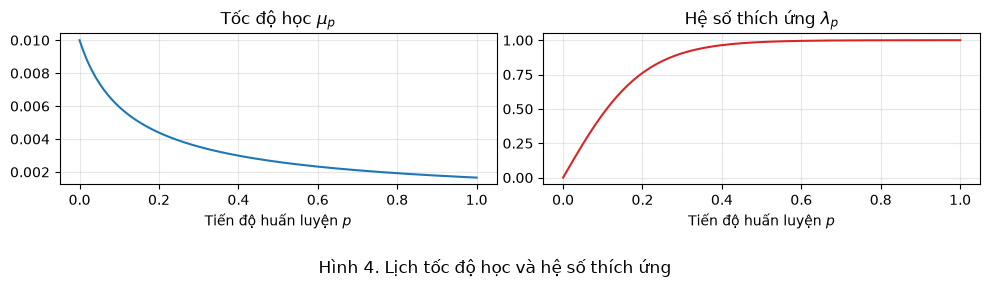

,p,mu_p,lambda_p
0,0.0,0.01000,0.0000
1,0.1,0.00595,0.4621
2,0.3,0.00354,0.9051
3,0.5,0.00261,0.9866
4,1.0,0.00166,0.9999


In [11]:
def lr_at(p):
    return MU0 / (1 + ALPHA * p) ** BETA


def lambda_at(p):
    return 2 / (1 + math.exp(-GAMMA * p)) - 1


ps = np.linspace(0, 1, 201)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(ps, [lr_at(p) for p in ps]); ax[0].set_title(r"Tốc độ học $\mu_p$")
ax[1].plot(ps, [lambda_at(p) for p in ps], color="tab:red"); ax[1].set_title(r"Hệ số thích ứng $\lambda_p$")
for a in ax:
    a.set_xlabel("Tiến độ huấn luyện $p$"); a.grid(alpha=0.3)
fig.suptitle("Hình 4. Lịch tốc độ học và hệ số thích ứng", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()
display(pd.DataFrame({"p": [0, 0.1, 0.3, 0.5, 1.0]}).assign(
    mu_p=lambda d: d.p.map(lr_at).round(5), lambda_p=lambda d: d.p.map(lambda_at).round(4)))

## 6. Huấn luyện và đánh giá

Sau mỗi epoch, mô hình được đánh giá trên tập test của hai miền:

- Độ chính xác nguồn $a_S$ và độ chính xác đích $a_T$: tỉ lệ ảnh dự đoán đúng nhãn,
  $a = \frac{1}{n}\sum_{i} \mathbb{1}[\hat{y}_i = y_i]$.
- Với DANN, độ chính xác của bộ phân loại miền $a_d$ trên 10 000 ảnh test MNIST (nhãn miền 0) và 10 000 ảnh
  test MNIST-M (nhãn miền 1), với quy tắc đoán miền đích khi logit $G_d > 0$. $a_d$ càng gần 0,5 thì hai miền
  càng khó phân biệt trong không gian đặc trưng.

**Chọn epoch không dùng nhãn đích.** Ganin và Lempitsky (2015, mục 4) nhận xét thích ứng thành công hơn khi
sai số kiểm thử trên miền nguồn thấp và sai số của bộ phân loại miền cao. Từ nhận xét đó, quy tắc chọn epoch
$e^*$ cho DANN là

$$
\mathcal{E}^* = \left\{ e : a_S(e) \ge \max_{e'} a_S(e') - 0{,}01 \right\},
\qquad
e^* = \arg\max_{e \in \mathcal{E}^*} \big(1 - a_d(e)\big),
$$

trùng thì lấy epoch sau. Quy tắc chỉ dùng $a_S$ và $a_d$; $a_T$ được ghi lại để phân tích, không tham gia chọn.
Kết quả báo cáo cả epoch cuối và epoch $e^*$.

In [12]:
@torch.no_grad()
def accuracy(model, X, Y, bs=2000):
    model.eval()
    correct = sum((model(prep(X[i:i + bs])).argmax(1) == Y[i:i + bs]).sum().item()
                  for i in range(0, len(X), bs))
    return correct / len(X)


@torch.no_grad()
def domain_accuracy(model, bs=2000):
    model.eval()
    correct = 0
    for X, dom in [(S_te, 0), (T_te, 1)]:
        for i in range(0, len(X), bs):
            _, d = model(prep(X[i:i + bs]), with_domain=True)
            correct += ((d > 0).long() == dom).sum().item()
    return correct / (len(S_te) + len(T_te))


def train(method, seed):
    set_seed(seed)
    g = torch.Generator().manual_seed(seed)       # thứ tự lấy mẫu
    model = DANN().to(device)
    opt = torch.optim.SGD(model.parameters(), lr=MU0, momentum=MOMENTUM)
    if method == "dann":
        X, Y, bs = S_tr, yS_tr, BATCH // 2
    else:
        X, Y, bs = (T_tr, yT_tr, BATCH) if method == "target" else (S_tr, yS_tr, BATCH)
    steps_per_epoch = len(X) // bs
    total = steps_per_epoch * EPOCHS
    history, snapshots, step, train_s = [], {}, 0, 0.0
    for epoch in range(1, EPOCHS + 1):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        model.train()
        perm = torch.randperm(len(X), generator=g).to(device)
        perm_t = torch.randperm(len(T_tr), generator=g).to(device) if method == "dann" else None
        for b in range(steps_per_epoch):
            p = step / total
            for grp in opt.param_groups:
                grp["lr"] = lr_at(p)
            idx = perm[b * bs:(b + 1) * bs]
            xs, ys = prep(X[idx]), Y[idx]
            if method == "dann":
                xt = prep(T_tr[perm_t[b * bs:(b + 1) * bs]])          # bỏ nhãn đích
                x = torch.cat([xs, xt])
                d = torch.cat([torch.zeros(bs, device=device), torch.ones(bs, device=device)])
                logits, d_logits = model(x, lambd=lambda_at(p), with_domain=True)
                loss = F.cross_entropy(logits[:bs], ys) + F.binary_cross_entropy_with_logits(d_logits, d)
            else:
                loss = F.cross_entropy(model(xs), ys)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            step += 1
        if device.type == "cuda":
            torch.cuda.synchronize()
        train_s += time.time() - t0
        rec = {"epoch": epoch, "source_test_acc": accuracy(model, S_te, yS_te),
               "target_test_acc": accuracy(model, T_te, yT_te)}
        if method == "dann":
            rec["domain_acc"] = domain_accuracy(model)
            snapshots[epoch] = copy.deepcopy(model.state_dict())
        history.append(rec)
        extra = f" a_d={rec['domain_acc']:.4f}" if method == "dann" else ""
        print(f"[{method} seed {seed}] epoch {epoch:2d}/{EPOCHS} a_S={rec['source_test_acc']:.4f} "
              f"a_T={rec['target_test_acc']:.4f}{extra} ({train_s:.0f} s)")
    res = {"method": method, "seed": seed, "norm": NORM, "norm_mean": list(MEAN), "epochs": EPOCHS,
           "steps": total, "source_test_acc": history[-1]["source_test_acc"],
           "target_test_acc": history[-1]["target_test_acc"], "train_seconds": round(train_s, 1),
           "environment": env, "history": history, "selected": None}
    sel_model = None
    if method == "dann":
        best = max(h["source_test_acc"] for h in history)
        ok = [h for h in history if h["source_test_acc"] >= best - 0.01]
        h = max(ok, key=lambda h: (1 - h["domain_acc"], h["epoch"]))
        res["selected"] = {k: h[k] for k in ("epoch", "source_test_acc", "domain_acc", "target_test_acc")}
        sel_model = DANN().to(device)
        sel_model.load_state_dict(snapshots[h["epoch"]])
    name = f"{method}_seed{seed}_{NORM}"
    (OUT_DIR / f"{name}.json").write_text(json.dumps(res, indent=2), encoding="utf-8")
    torch.save(model.state_dict(), OUT_DIR / f"{name}.pt")
    return res, model.eval(), sel_model

## 7. Chạy huấn luyện

Mỗi seed huấn luyện ba mô hình. Kết quả (`.json`) và trọng số (`.pt`) ghi vào thư mục `results/`, tải về được
từ thanh bên *Files* của Colab.

In [13]:
RESULTS, MODELS = [], {}
for seed in SEEDS:
    for method in ["baseline", "dann", "target"]:
        res, model, sel = train(method, seed)
        RESULTS.append(res)
        MODELS[(method, seed)] = model
        if sel is not None:
            MODELS[("dann_selected", seed)] = sel

[baseline seed 42] epoch  1/20 a_S=0.9705 a_T=0.4695 (2 s)


[baseline seed 42] epoch  2/20 a_S=0.9811 a_T=0.5011 (3 s)


[baseline seed 42] epoch  3/20 a_S=0.9853 a_T=0.5063 (4 s)


[baseline seed 42] epoch  4/20 a_S=0.9867 a_T=0.5246 (6 s)


[baseline seed 42] epoch  5/20 a_S=0.9872 a_T=0.5325 (7 s)


...

[target seed 42] epoch 16/20 a_S=0.9861 a_T=0.9717 (23 s)


[target seed 42] epoch 17/20 a_S=0.9860 a_T=0.9717 (24 s)


[target seed 42] epoch 18/20 a_S=0.9878 a_T=0.9728 (25 s)


[target seed 42] epoch 19/20 a_S=0.9861 a_T=0.9724 (26 s)


[target seed 42] epoch 20/20 a_S=0.9874 a_T=0.9720 (27 s)


## 8. Kết quả

### 8.1. Độ chính xác trên MNIST-M

Hai bản công bố báo cáo độ chính xác trên tập test MNIST-M: Ganin và Lempitsky (2015, Bảng 1) và Ganin và
cộng sự (2016, Bảng 2). Mức thích ứng được đo bằng tỉ lệ khoảng cách giữa cận dưới và cận trên mà DANN thu
hẹp được, theo cách trình bày trong Bảng 1 của bản 2015:

$$
G = \frac{a_T^{\text{DANN}} - a_T^{\text{baseline}}}{a_T^{\text{target}} - a_T^{\text{baseline}}}.
$$

Theo công thức này, bản 2015 thu hẹp $(0{,}8149 - 0{,}5749)/(0{,}9891 - 0{,}5749) \approx 57{,}9\%$. Tính
lại từ ba số của Bảng 2 bản 2016 cho khoảng $55{,}8\%$, trong khi bảng in $52{,}9\%$.

In [14]:
PAPER = pd.DataFrame({"ICML 2015 (Bảng 1)": [0.5749, 0.8149, 0.9891],
                      "JMLR 2016 (Bảng 2)": [0.5225, 0.7666, 0.9596]},
                     index=["baseline", "dann", "target"])

df = pd.DataFrame([{"seed": r["seed"], "method": r["method"], "a_S": r["source_test_acc"],
                    "a_T": r["target_test_acc"], "thời gian (s)": r["train_seconds"]} for r in RESULTS])
sel = pd.DataFrame([{"seed": r["seed"], "method": "dann (epoch chọn)", "a_S": r["selected"]["source_test_acc"],
                     "a_T": r["selected"]["target_test_acc"], "epoch": r["selected"]["epoch"]}
                    for r in RESULTS if r["selected"]])
per_seed = pd.concat([df, sel], ignore_index=True).sort_values(["seed", "method"])
display(per_seed.round(4))

a = df.pivot(index="seed", columns="method", values="a_T")
a["dann (epoch chọn)"] = sel.set_index("seed")["a_T"]
gap = pd.DataFrame({"G (epoch cuối)": (a.dann - a.baseline) / (a.target - a.baseline),
                    "G (epoch chọn)": (a["dann (epoch chọn)"] - a.baseline) / (a.target - a.baseline)})
summary = pd.DataFrame({"Tái lập (trung bình)": a.mean(),
                        "Độ lệch chuẩn": a.std(ddof=1) if len(a) > 1 else np.nan}).join(PAPER)
display(summary.round(4))
display(gap.agg(["mean"]).rename(index={"mean": "trung bình"}).round(4) if len(gap) > 1 else gap.round(4))

,seed,method,a_S,a_T,thời gian (s),epoch
0,42,baseline,0.9902,0.5402,29.2,NaN
1,42,dann,0.9871,0.8539,112.9,NaN
3,42,dann (epoch chọn),0.9858,0.7709,NaN,9.0
2,42,target,0.9874,0.9720,27.3,NaN


,Tái lập (trung bình),Độ lệch chuẩn,ICML 2015 (Bảng 1),JMLR 2016 (Bảng 2)
method,,,,
baseline,0.5402,NaN,0.5749,0.5225
dann,0.8539,NaN,0.8149,0.7666
target,0.9720,NaN,0.9891,0.9596
dann (epoch chọn),0.7709,NaN,NaN,NaN


,G (epoch cuối),G (epoch chọn)
seed,,
42,0.7265,0.5343


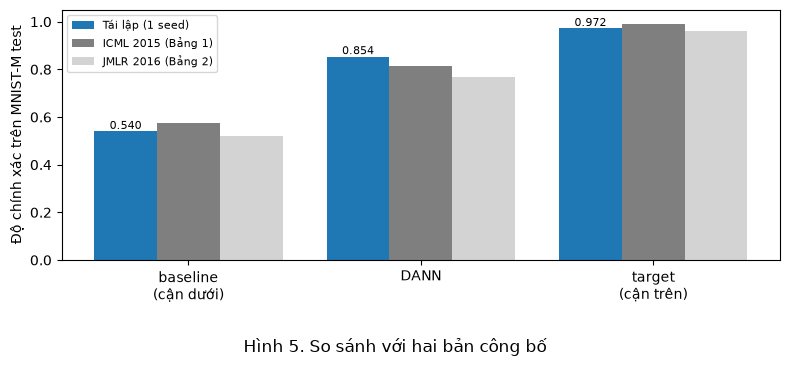

In [15]:
order = ["baseline", "dann", "target"]
x = np.arange(3)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(x - 0.27, a[order].mean(), 0.27, yerr=a[order].std(ddof=1) if len(a) > 1 else None,
       label=f"Tái lập ({len(a)} seed)", color="tab:blue")
ax.bar(x, PAPER.iloc[:, 0], 0.27, label=PAPER.columns[0], color="tab:gray")
ax.bar(x + 0.27, PAPER.iloc[:, 1], 0.27, label=PAPER.columns[1], color="lightgray")
for i, v in enumerate(a[order].mean()):
    ax.text(i - 0.27, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
ax.set_xticks(x, ["baseline\n(cận dưới)", "DANN", "target\n(cận trên)"])
ax.set_ylim(0, 1.05); ax.set_ylabel("Độ chính xác trên MNIST-M test"); ax.legend(fontsize=8, loc="upper left")
fig.suptitle("Hình 5. So sánh với hai bản công bố", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### 8.2. Diễn biến theo epoch

Hình 6 vẽ $a_S$, $a_T$ của `baseline` và DANN cùng $a_d$ của DANN theo epoch (seed đầu tiên trong `SEEDS`).
Đường nét đứt đánh dấu epoch $e^*$ do quy tắc ở mục 6 chọn.

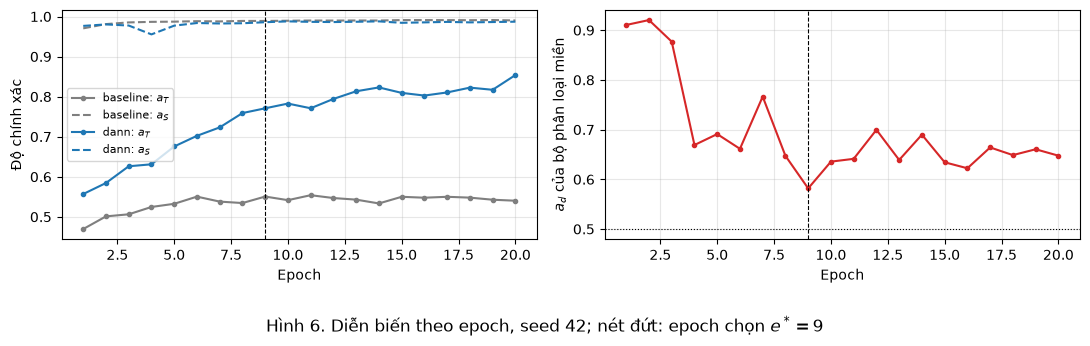

In [16]:
s0 = SEEDS[0]
H = {r["method"]: pd.DataFrame(r["history"]) for r in RESULTS if r["seed"] == s0}
e_star = next(r["selected"]["epoch"] for r in RESULTS if r["seed"] == s0 and r["selected"])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for m, c in [("baseline", "tab:gray"), ("dann", "tab:blue")]:
    ax[0].plot(H[m].epoch, H[m].target_test_acc, "-o", ms=3, color=c, label=f"{m}: $a_T$")
    ax[0].plot(H[m].epoch, H[m].source_test_acc, "--", color=c, label=f"{m}: $a_S$")
ax[0].set_ylabel("Độ chính xác"); ax[0].legend(fontsize=8)
ax[1].plot(H["dann"].epoch, H["dann"].domain_acc, "-o", ms=3, color="tab:red")
ax[1].axhline(0.5, color="k", lw=0.8, ls=":")
ax[1].set_ylabel("$a_d$ của bộ phân loại miền")
for a_ in ax:
    a_.axvline(e_star, color="k", ls="--", lw=0.8)
    a_.set_xlabel("Epoch"); a_.grid(alpha=0.3)
fig.suptitle(f"Hình 6. Diễn biến theo epoch, seed {s0}; nét đứt: epoch chọn $e^* = {e_star}$", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### 8.3. Phân bố đặc trưng (t-SNE)

Ganin và Lempitsky (2015, Hình 3) chiếu đặc trưng ở đầu ra bộ trích đặc trưng bằng t-SNE (van der Maaten và
Hinton, 2008), tô màu theo miền, và ghi nhận độ chính xác trên miền đích tương ứng với mức chồng lấp giữa hai
phân bố. Hình 7 làm lại phép chiếu này cho 1 000 ảnh test mỗi miền, với đặc trưng 768 chiều của $G_f$.

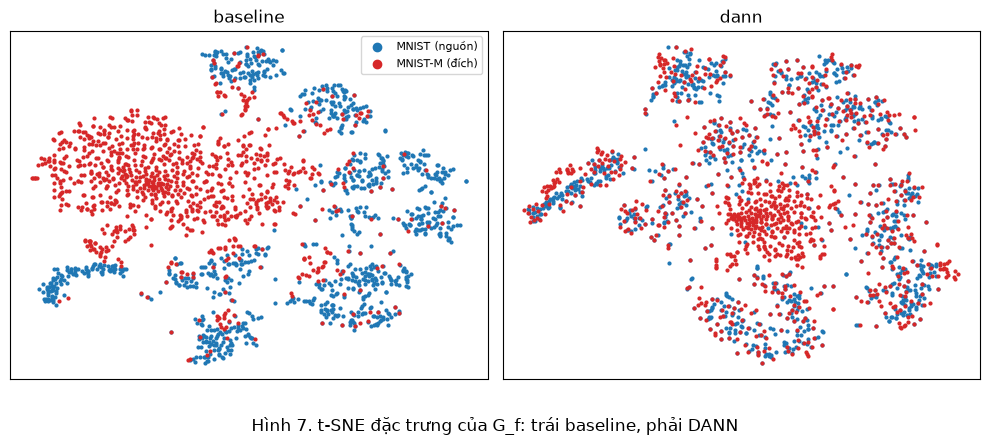

In [17]:
from sklearn.manifold import TSNE

idx = torch.randperm(len(S_te), generator=torch.Generator().manual_seed(0))[:1000].to(device)


@torch.no_grad()
def feats(model):
    model.eval()
    return torch.cat([model.features(prep(S_te[idx])), model.features(prep(T_te[idx]))]).cpu().numpy()


fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
for a_, m in zip(ax, ["baseline", "dann"]):
    z = TSNE(n_components=2, init="pca", perplexity=30, random_state=0).fit_transform(feats(MODELS[(m, s0)]))
    a_.scatter(*z[:1000].T, s=4, c="tab:blue", label="MNIST (nguồn)")
    a_.scatter(*z[1000:].T, s=4, c="tab:red", label="MNIST-M (đích)")
    a_.set_title(m); a_.set_xticks([]); a_.set_yticks([])
ax[0].legend(markerscale=3, fontsize=8)
fig.suptitle("Hình 7. t-SNE đặc trưng của G_f: trái baseline, phải DANN", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### 8.4. Ma trận nhầm lẫn và ví dụ

Hàng là nhãn thật, cột là nhãn dự đoán, trên 10 000 ảnh test MNIST-M; mỗi hàng chuẩn hóa về tổng 1.

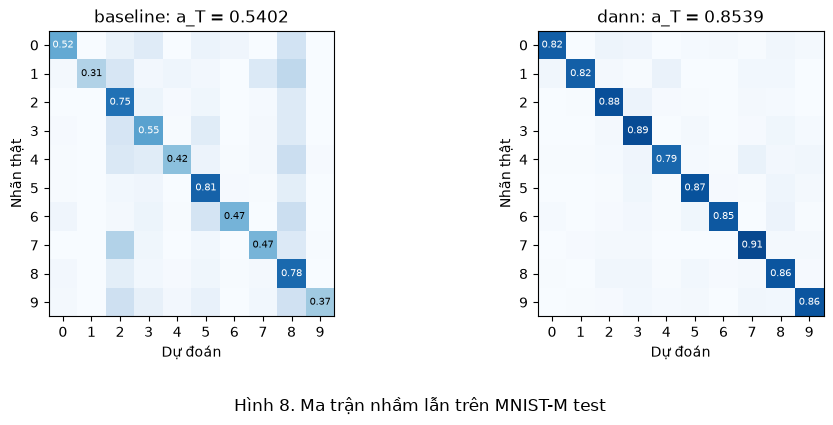

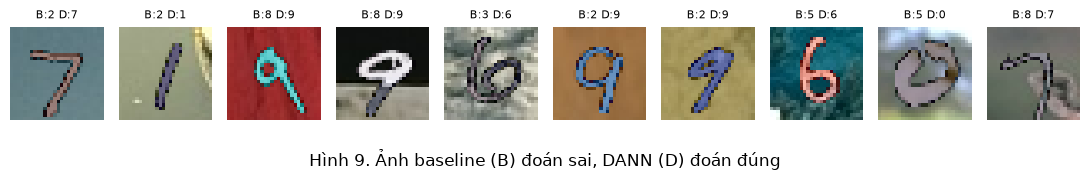

Số ảnh baseline sai, DANN đúng: 3549; baseline đúng, DANN sai: 412


In [18]:
@torch.no_grad()
def predict(model, X, bs=2000):
    model.eval()
    return torch.cat([model(prep(X[i:i + bs])).argmax(1) for i in range(0, len(X), bs)])


pred = {m: predict(MODELS[(m, s0)], T_te) for m in ["baseline", "dann"]}
yt = yT_te.cpu().numpy()
fig, ax = plt.subplots(1, 2, figsize=(10, 4.4))
for a_, m in zip(ax, ["baseline", "dann"]):
    cm = np.zeros((10, 10))
    np.add.at(cm, (yt, pred[m].cpu().numpy()), 1)
    cm /= cm.sum(1, keepdims=True)
    a_.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    for i in range(10):
        a_.text(i, i, f"{cm[i, i]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if cm[i, i] > 0.5 else "black")
    a_.set_title(f"{m}: a_T = {(pred[m] == yT_te).float().mean().item():.4f}")
    a_.set_xticks(range(10)); a_.set_yticks(range(10))
    a_.set_xlabel("Dự đoán"); a_.set_ylabel("Nhãn thật")
fig.suptitle("Hình 8. Ma trận nhầm lẫn trên MNIST-M test", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

fixed = torch.where((pred["baseline"] != yT_te) & (pred["dann"] == yT_te))[0][:10].cpu().numpy()
fig, ax = plt.subplots(1, len(fixed), figsize=(1.1 * len(fixed), 1.8))
for a_, i in zip(np.atleast_1d(ax), fixed):
    a_.imshow(mnistm_te[i]); a_.axis("off")
    a_.set_title(f"B:{pred['baseline'][i].item()} D:{pred['dann'][i].item()}", fontsize=8)
fig.suptitle("Hình 9. Ảnh baseline (B) đoán sai, DANN (D) đoán đúng", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()
print(f"Số ảnh baseline sai, DANN đúng: {((pred['baseline'] != yT_te) & (pred['dann'] == yT_te)).sum().item()}; "
      f"baseline đúng, DANN sai: {((pred['baseline'] == yT_te) & (pred['dann'] != yT_te)).sum().item()}")

### 8.5. Đối chiếu với kết quả của repo

Repo [dann-mnist-mnistm](https://github.com/ThuanNP/dann-mnist-mnistm) chạy cùng cấu hình bằng `DataLoader`
trên GPU NVIDIA RTX A4000 Laptop, ba seed (42, 43, 44) cho mỗi cách tiền xử lý, 18 lần huấn luyện (thư mục
`runs/gen-half` và `runs/gen-mean`). Bảng dưới ghi trung bình ± độ lệch chuẩn mẫu của độ chính xác trên
MNIST-M test, đặt cạnh kết quả của notebook. Thứ tự lấy mẫu khác nhau nên kết quả cùng seed của hai bên không trùng nhau.

In [19]:
REPO = pd.DataFrame({
    "repo, half": ["0.5401 ± 0.0269", "0.8061 ± 0.0280", "0.7681 ± 0.0485", "0.9726 ± 0.0003"],
    "repo, mean": ["0.5144 ± 0.0335", "0.7996 ± 0.0091", "0.7533 ± 0.0571", "0.9730 ± 0.0006"]},
    index=["baseline", "dann", "dann (epoch chọn)", "target"])
fmt = lambda m, s: f"{m:.4f}" + (f" ± {s:.4f}" if not np.isnan(s) else "")
REPO[f"notebook, {NORM} ({len(a)} seed)"] = [fmt(a[c].mean(), a[c].std(ddof=1) if len(a) > 1 else np.nan)
                                             for c in REPO.index]
display(REPO)

,"repo, half","repo, mean","notebook, half (1 seed)"
baseline,0.5401 ± 0.0269,0.5144 ± 0.0335,0.5402
dann,0.8061 ± 0.0280,0.7996 ± 0.0091,0.8539
dann (epoch chọn),0.7681 ± 0.0485,0.7533 ± 0.0571,0.7709
target,0.9726 ± 0.0003,0.9730 ± 0.0006,0.9720


## 9. Kết luận và giới hạn

- Trên ba seed của repo (trừ 0,5), DANN nâng độ chính xác trên MNIST-M từ 0,540 của `baseline` lên 0,806 ở
  epoch cuối, sát mức 0,8149 của bản 2015, và thu hẹp khoảng 61,5% khoảng cách tới cận trên; độ chính xác trên
  MNIST giảm từ 0,991 xuống 0,987. Độ lệch chuẩn giữa ba seed khoảng 0,03, nên kết quả của một seed như ở
  mục 8 có thể lệch vài điểm phần trăm quanh mức trung bình.
- Trên hình t-SNE của `baseline`, đặc trưng MNIST-M dồn thành một cụm lớn tách khỏi các cụm chữ số của MNIST.
  Với DANN, hai miền chồng lấp trên phần lớn các cụm, khớp với quan sát ở Hình 3 của Ganin và Lempitsky (2015).
- Sau vài epoch đầu, $a_d$ của DANN dao động trong khoảng 0,6 đến 0,7 thay vì về 0,5: bộ phân loại miền vẫn
  phân biệt được một phần hai miền, tức đặc trưng chưa bất biến hoàn toàn theo miền.
- Ở cả sáu cặp seed và cách tiền xử lý của repo, epoch chọn theo quy tắc không dùng nhãn đích cho $a_T$ thấp
  hơn epoch cuối (trung bình 0,768 so với 0,806 khi trừ 0,5). Các epoch được chọn ở repo nằm trong khoảng epoch
  8 đến 13, khi $a_T$ còn đang tăng.

Giới hạn:

- MNIST-M dựng lại theo công thức bài báo; ảnh nền và vị trí cắt ngẫu nhiên khác bản của Ganin và Lempitsky,
  nên độ khó của miền đích có thể khác.
- Ba chi tiết bài báo không nêu (số seed, cách tính trung bình khi tiền xử lý, số bước huấn luyện) được
  chọn như mục 2.
- Kết quả phụ thuộc seed và GPU; cùng seed trên phần cứng khác có thể lệch nhỏ.

## Tài liệu tham khảo

- Arbelaez, P., Maire, M., Fowlkes, C., & Malik, J. (2011). Contour detection and hierarchical image
  segmentation. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 33*(5), 898-916.
- Ben-David, S., Blitzer, J., Crammer, K., & Pereira, F. (2006). Analysis of representations for domain
  adaptation. *Advances in Neural Information Processing Systems 19*.
- Ganin, Y., & Lempitsky, V. (2015). Unsupervised domain adaptation by backpropagation. *Proceedings of the
  32nd International Conference on Machine Learning*, PMLR 37, 1180-1189. [arXiv:1409.7495](https://arxiv.org/abs/1409.7495)
- Ganin, Y., Ustinova, E., Ajakan, H., Germain, P., Larochelle, H., Laviolette, F., Marchand, M., & Lempitsky, V.
  (2016). Domain-adversarial training of neural networks. *Journal of Machine Learning Research, 17*(59), 1-35.
  [arXiv:1505.07818](https://arxiv.org/abs/1505.07818)
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document
  recognition. *Proceedings of the IEEE, 86*(11), 2278-2324.
- van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *Journal of Machine Learning
  Research, 9*, 2579-2605.